# 🔢 Laboratório de Álgebra Linear
Notebook de referência cobrindo os principais tópicos com NumPy (numérico) e SymPy (simbólico).

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

sp.init_printing()  # imprime expressões simbólicas de forma bonita
print('✅ Ambiente pronto!')

✅ Ambiente pronto!


## 1. Operações básicas com matrizes

In [2]:
A = np.array([[2, 1],
              [5, 3]])

B = np.array([[1, 0],
              [2, 1]])

print('A @ B (produto matricial):\n', A @ B)
print('\nTransposta de A:\n', A.T)
print('\nDeterminante de A:', np.linalg.det(A))
print('\nInversa de A:\n', np.linalg.inv(A))

A @ B (produto matricial):
 [[ 4  1]
 [11  3]]

Transposta de A:
 [[2 5]
 [1 3]]

Determinante de A: 1.0000000000000009

Inversa de A:
 [[ 3. -1.]
 [-5.  2.]]


## 2. Sistemas lineares — Ax = b

In [3]:
# Resolve o sistema:  2x + y = 5
#                     5x + 3y = 13
A = np.array([[2., 1.],
              [5., 3.]])
b = np.array([5., 13.])

x = np.linalg.solve(A, b)
print('Solução x:', x)
print('Verificação A @ x == b:', np.allclose(A @ x, b))

Solução x: [2. 1.]
Verificação A @ x == b: True


## 3. Autovalores e Autovetores

Autovalores: [5. 2.]
Autovetores (colunas):
 [[ 0.89442719 -0.70710678]
 [ 0.4472136   0.70710678]]


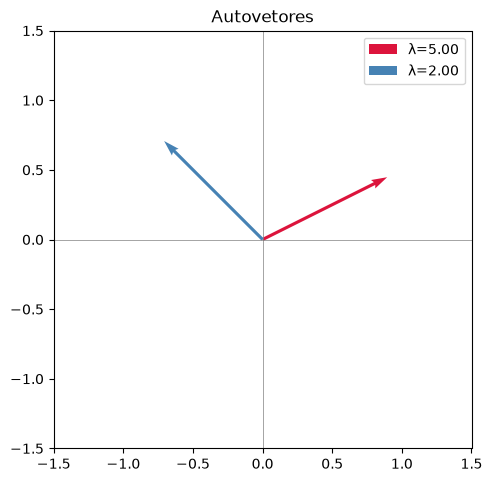

In [4]:
A = np.array([[4., 2.],
              [1., 3.]])

autovalores, autovetores = np.linalg.eig(A)

print('Autovalores:', autovalores)
print('Autovetores (colunas):\n', autovetores)

# Visualizar os autovetores
fig, ax = plt.subplots(figsize=(5, 5))
origin = [0, 0]
colors = ['crimson', 'steelblue']
for i in range(2):
    ax.quiver(*origin, autovetores[0, i], autovetores[1, i],
              scale=1, scale_units='xy', angles='xy',
              color=colors[i], label=f'λ={autovalores[i]:.2f}')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.legend()
ax.set_title('Autovetores')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 4. Decomposições — LU, QR, SVD

In [ ]:
from scipy.linalg import lu, qr

A = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [7., 8., 10.]])

# LU
P, L, U = lu(A)
print('=== Decomposição LU ===')
print('L:\n', L.round(3))
print('U:\n', U.round(3))

# SVD
U_svd, S, Vt = np.linalg.svd(A)
print('\n=== SVD — Valores Singulares ===')
print(S.round(4))

# QR
Q, R = qr(A)
print('\n=== Decomposição QR ===')
print('Q ortogonal? Q.T @ Q ≈ I:', np.allclose(Q.T @ Q, np.eye(3)))

## 5. Álgebra Simbólica com SymPy

In [ ]:
a, b, c, x, y = sp.symbols('a b c x y')

# Matriz simbólica
M = sp.Matrix([[a, b],
               [c, 1]])

print('Determinante:')
display(M.det())

print('\nInversa:')
display(M.inv())

print('\nPolinômio característico (autovalores):')
lam = sp.Symbol('lambda')
display(M.charpoly(lam).as_expr())

## 6. Visualização — Transformação Linear em 2D

In [ ]:
# Visualizar o efeito de uma transformação linear numa grade de vetores
T = np.array([[2., 1.],
              [0., 1.5]])

# Grade original
xs = np.linspace(-2, 2, 8)
ys = np.linspace(-2, 2, 8)
pontos = np.array([[x, y] for x in xs for y in ys])
transformados = (T @ pontos.T).T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(pontos[:, 0], pontos[:, 1], s=10, color='steelblue')
ax1.set_title('Espaço original')
ax1.set_aspect('equal')
ax1.axhline(0, color='gray', lw=0.5)
ax1.axvline(0, color='gray', lw=0.5)

ax2.scatter(transformados[:, 0], transformados[:, 1], s=10, color='crimson')
ax2.set_title(f'Após transformação T')
ax2.set_aspect('equal')
ax2.axhline(0, color='gray', lw=0.5)
ax2.axvline(0, color='gray', lw=0.5)

plt.suptitle('Efeito da transformação linear', fontsize=13)
plt.tight_layout()
plt.show()